# Calcolo LTM nel formalismo stabilizer

## General construction of the LTM canonical form

In [1]:
import numpy as np
from scipy.sparse.csgraph import connected_components

tol = 1e-16

def canonical_form(T, tol=tol):

    connectivity = (np.abs(T) > tol).astype(int)

    # Trova i componenti connessi (trattando la matrice come grafo non diretto)
    n_components, comp_labels = connected_components(connectivity, directed=False, connection='strong')
    print(n_components)

    # La permutazione che raggruppa per componente è data da:
    permutation = np.argsort(comp_labels)
    # Riordiniamo T per ottenere una forma bloc-diagonale
    T_perm = T[permutation, :][:, permutation]

    # Salviamo la mappatura della permutazione: (nuovo indice -> indice originale)
    perm_mapping = {new_idx: old_idx for new_idx, old_idx in enumerate(permutation)}
    return T_perm, permutation

In [2]:
import matplotlib.pyplot as plt

def heatmap_plot(T):

    plt.figure(figsize=(8, 6))
    plt.imshow(np.abs(T), cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.xlabel("Entrata località")
    plt.ylabel("Uscita località")
    plt.title("Heatmap della matrice T")
    plt.show()

In [3]:
from ltm.clifford_circuit import CliffordCircuit

N = 7
C = 2

# Costruisce un circuito clifford associato al blocco W.
# Questo funziona se W si puo scomporre in CNOT, H ed S.
def W_circuit(N, C):

    circ = CliffordCircuit(N)
    circ.CNOT(1,0)
    for c in range(C):
        for i in range(0,N-2):
            circ.CNOT(i%N, (i+2)%N)
    return circ

W = W_circuit(N, C)
print(W)

['CNOT(1->0)', 'CNOT(0->2)', 'CNOT(1->3)', 'CNOT(2->4)', 'CNOT(3->5)', 'CNOT(4->6)', 'CNOT(0->2)', 'CNOT(1->3)', 'CNOT(2->4)', 'CNOT(3->5)', 'CNOT(4->6)']


### No-noise LTM

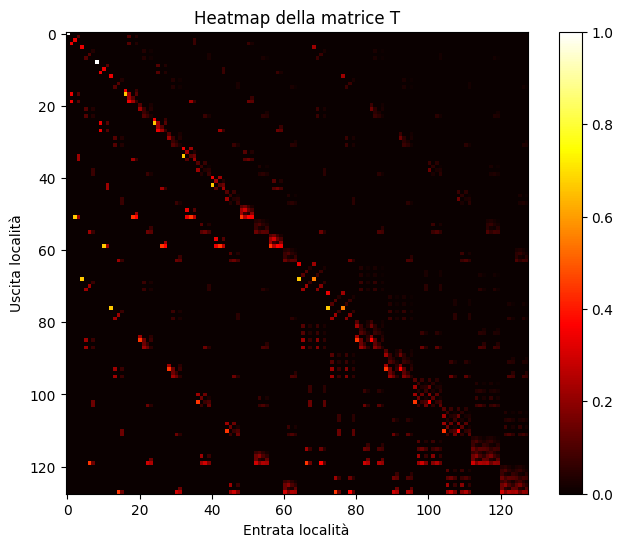

In [4]:
from ltm.utils import clifford_LTM

W = W_circuit(N, C)
LTM = clifford_LTM(W)
heatmap_plot(LTM)

8


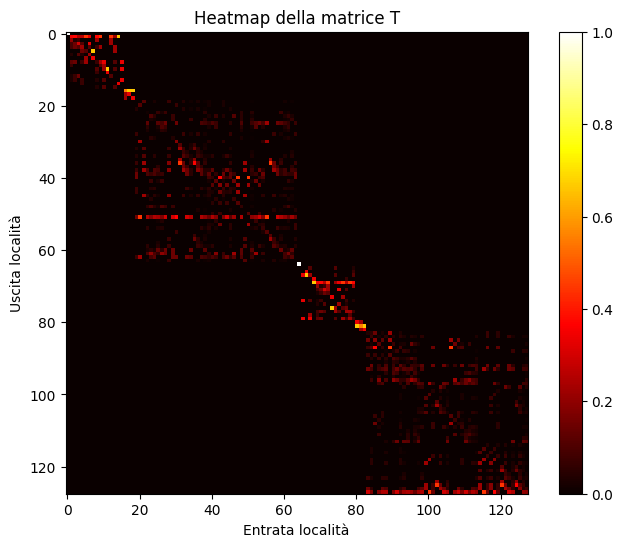

In [5]:
canonical_LTM, permutation = canonical_form(LTM)
heatmap_plot(canonical_LTM)

In [6]:
print([bin(p)[2:] for p in permutation])

['0', '110011', '110010', '110001', '100011', '100010', '100001', '100000', '10011', '10010', '10001', '10000', '110000', '11', '10', '1', '1000100', '100', '1000000', '1000011', '1000010', '1000001', '110110', '1110001', '1110010', '110111', '110101', '110100', '1000101', '1110000', '1000110', '1010000', '1010001', '1010010', '1010011', '1010100', '1010101', '1010110', '1010111', '1100111', '1100110', '1100101', '1100100', '1100011', '1100010', '1000111', '1100001', '1100000', '1110100', '101', '100100', '1110111', '100101', '100110', '100111', '110', '10100', '10101', '10110', '10111', '1110110', '1110101', '1110011', '111', '1000', '1001', '11000', '11001', '1010', '111011', '111010', '111001', '111000', '101000', '1011', '101001', '101010', '101011', '11010', '11011', '1001000', '1001100', '1100', '1101010', '1101011', '1101100', '1101101', '1101110', '1111010', '1101000', '1111001', '1111000', '1101111', '1111011', '1111100', '1101001', '1111101', '111111', '1011110', '1101', '111

### Adding simple noise

In [7]:
from ltm.noise import AmplitudeDamping, Depolarizing, single_qubit_noise_map

adc = AmplitudeDamping(1)
dc = Depolarizing(0.1)

# Il noise viene rappresentato con un modello ad hoc compatibile con la simulazione nel formalismo stabilizer.
# Interpretazione: sul qubit 1 applica un canale di amplitude damping, sul 3 un altro amplitude damping e cosi via
noise_model = [(1, adc),(3, adc),(5, adc)]

# Genera la mappa corrispondente al modello descritto sopra
noise_map = single_qubit_noise_map(noise_model)

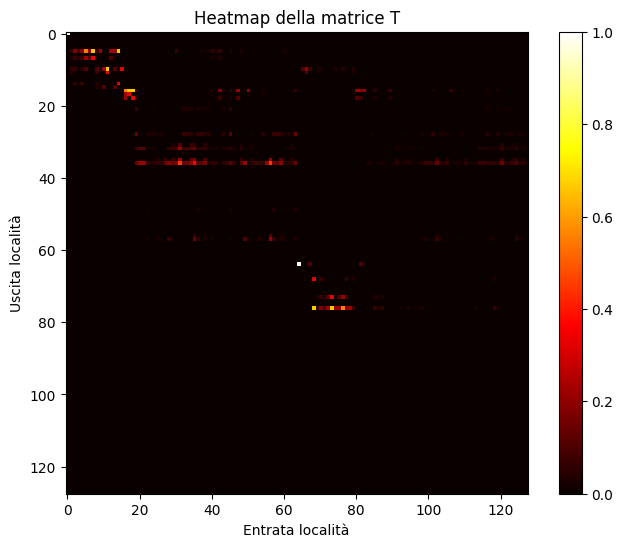

In [8]:
nLTM = clifford_LTM(W, noise_map=noise_map)
canonical_nLTM = nLTM[permutation, :][:, permutation]
#canonical_nLTM, npermutation = canonical_form(nLTM)
heatmap_plot(canonical_nLTM)

### Analytical calculation of the variance

To be checked

In [23]:
from stabilizer import Pauli
from ltm.utils import combination_of_pauli_lv

#H = [(1.0, u.Pauli(u._add_identity(list('ZZZ'),bin(5<<n)[2:]))) for n in range(N-2)]
#H += [(1.0, u.Pauli(u._add_identity(list('X'),bin(1<<n)[2:]))) for n in range(N)]
H = [(1.0, Pauli('XXIXI'))]

hlv = combination_of_pauli_lv(H, N)
print(hlv)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


In [24]:
def analytical_variance(LTM, l_rho, l_H, L):
    from ltm.utils import vardot

    for _ in range(L):
        l_H = LTM@l_H
    return vardot(l_rho, l_H)

In [25]:
l_0 = np.ones(2**N)
L = 10
print([analytical_variance(nLTM, l_0, hlv, l) for l in range(L)])

[0.037037037037037035, 0.008230452674897118, 0.010973936899862825, 0.009653000050805263, 0.008151422265124443, 0.006890699061607969, 0.005822882537324968, 0.004920715486474955, 0.004158303563547462, 0.003514021494939381]
